# 01 — EDA: Industrial Failure Classification

Dataset: AI4I 2020 Predictive Maintenance (UCI)
https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset

Goals:
- Understand class imbalance (~3.4% failure rate)
- Visualize feature distributions by failure class
- Identify which sensors correlate most with failure
- Understand failure modes (TWF, HDF, PWF, OSF, RNF)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys; sys.path.insert(0, '..')
from src.features import download_data, load_raw, build_features, TARGET_COL, FAILURE_MODE_COLS

%matplotlib inline
sns.set_theme(style='darkgrid', palette='muted')

In [2]:
# Download data if needed
download_data()
df = load_raw()
print(df.shape)
df.head()

[features] Already exists: /Users/alvinalias/Library/Mobile Documents/com~apple~CloudDocs/Documents/Data Science/Resume/Portfolio Build/active/industrial_failure_classification/data/raw/ai4i2020.csv
[features] Loaded 10,000 rows | Failure rate: 3.4%
(10000, 13)


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type,Product ID
0,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,M,M14860
1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,L,L47181
2,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,L,L47182
3,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,L,L47183
4,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,L,L47184


No Failure: 9,661 (96.6%)
Failure:    339 (3.4%)


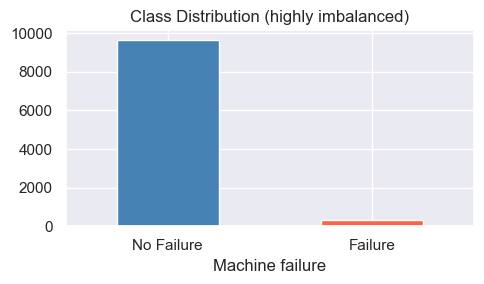

In [3]:
# Class distribution
fail_counts = df[TARGET_COL].value_counts()
print(f"No Failure: {fail_counts[0]:,} ({fail_counts[0]/len(df)*100:.1f}%)")
print(f"Failure:    {fail_counts[1]:,} ({fail_counts[1]/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 3))
fail_counts.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_xticklabels(['No Failure', 'Failure'], rotation=0)
ax.set_title('Class Distribution (highly imbalanced)')
plt.tight_layout(); plt.show()

In [4]:
# Failure mode breakdown
mode_counts = df[FAILURE_MODE_COLS].sum().sort_values(ascending=False)
print("Failure modes:")
print(mode_counts)

Failure modes:
HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64


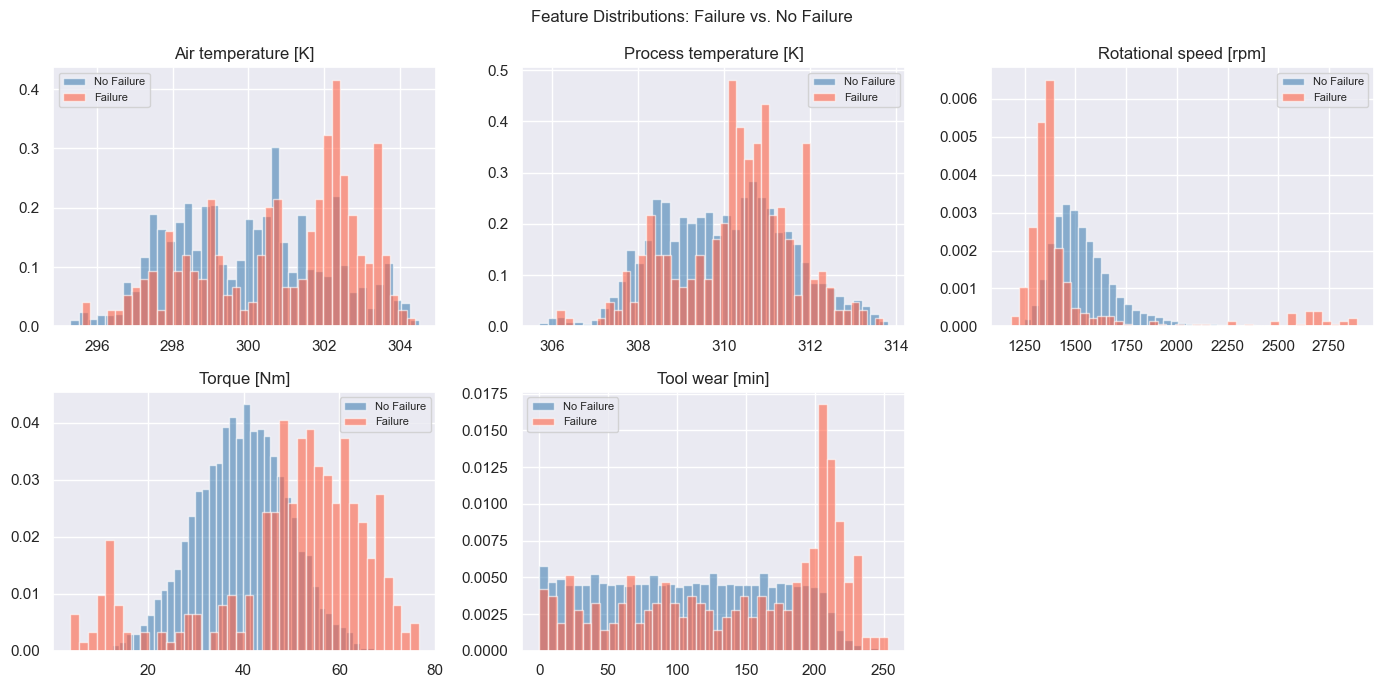

In [5]:
# Feature distributions: failure vs. no failure
raw_features = ['Air temperature [K]', 'Process temperature [K]',
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, feat in enumerate(raw_features):
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        axes[i].hist(df[df[TARGET_COL]==label][feat], bins=40, alpha=0.6,
                     label=f"{'Failure' if label else 'No Failure'}", color=color, density=True)
    axes[i].set_title(feat)
    axes[i].legend(fontsize=8)

axes[-1].axis('off')
plt.suptitle('Feature Distributions: Failure vs. No Failure', fontsize=12)
plt.tight_layout(); plt.show()

In [6]:
# Point biserial correlations with target
from scipy.stats import pointbiserialr

corr_data = []
for feat in raw_features:
    r, p = pointbiserialr(df[TARGET_COL], df[feat])
    corr_data.append({'feature': feat, 'correlation': r, 'p_value': p})

corr_df = pd.DataFrame(corr_data).sort_values('correlation', ascending=False)
print(corr_df.to_string(index=False))
# Expected: Tool wear and Torque will be highest

                feature  correlation      p_value
            Torque [Nm]     0.191321 4.573805e-83
        Tool wear [min]     0.105448 3.976076e-26
    Air temperature [K]     0.082556 1.354800e-16
Process temperature [K]     0.035946 3.240058e-04
 Rotational speed [rpm]    -0.044188 9.853543e-06


In [7]:
# Engineered features
df_feat = build_features(df)
print(df_feat[['temp_diff', 'power', 'wear_rate', 'torque_per_wear', 'high_load']].describe())

          temp_diff         power     wear_rate  torque_per_wear     high_load
count  10000.000000  10000.000000  10000.000000     10000.000000  10000.000000
mean      10.000630  59967.147040      0.070918         1.324723      0.250000
std        1.001094  10193.093881      0.042590         4.735015      0.433034
min        7.600000  10966.800000      0.000000         0.026168      0.000000
25%        9.300000  53105.400000      0.034520         0.239975      0.000000
50%        9.800000  59883.900000      0.069949         0.371277      0.000000
75%       11.000000  66873.750000      0.105608         0.735153      0.250000
max       12.100000  99980.400000      0.185273        68.500000      1.000000


In [8]:
# Failure rate by type
type_fail = df.groupby('Type')[TARGET_COL].mean() * 100
print("Failure rate by machine type:")
print(type_fail.round(2))

Failure rate by machine type:
Type
H    2.09
L    3.92
M    2.77
Name: Machine failure, dtype: float64
